<style>
  pre, code {
    white-space: pre-wrap !important;
  }
</style>

*École Polytechnique de Montréal*

*Cours MTH2210 : Calcul scientifique pour ingénieurs*

*Session d'automne 2026*

# Laboratoire 0

| N'DRI Donatien    | PAQUETTE-RUFIANGE Antonin |
|-------------------|---------------------|
| Matricule 9999999 | Matricule 0000000   |

Date: 20 juillet 2026

# Table des matières
1. [Question 1](#Question-1)
    * [Question 1a)](#Question-1a)
    * [Question 1b)](#Question-1b)
    * [Question 1c)](#Question-1c)
2. [Question 2](#Question-2)
    * [Question 2a)](#Question-2a)
    * [Question 2b)](#Question-2b)
3. [Question 3](#Question-3)
    * [Question 3a)](#Question-3a)
    * [Question 3b)](#Question-3b)
    * [Question 3c)](#Question-3c)

In [54]:
# Importation des librairies

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Question 1

Le développement de Taylor de la fonction ex autour de $x=0$ est donné par
$$
    p_4(x) = 1+x+x^2/2 + x^3/6 + x^4/24
$$

On peut aussi obtenir une approximation de la fonction exponentielle ex à l’aide de
la fonction rationnelle:
$$
    r(x) = \frac{x^2 + 6x+12}{x^2-6x+12}
$$

## Question 1a)

Tracer sur un même graphique la fonction $\exp(x)$ et les approximations $p_4(x)$ et $r(x)$ sur l’intervalle $[-\ln(2)/2,\ln(2)/2]$.

In [55]:
def p4(x):
    f = 1 + x + x**2/2 + x**3/6 + x**4/24
    return f

def fct_r(x):
    f = (x**2 + 6*x + 12)/(x**2 - 6*x + 12)
    return f

x = np.linspace(-np.log(2)/2,np.log(2)/2, 250)

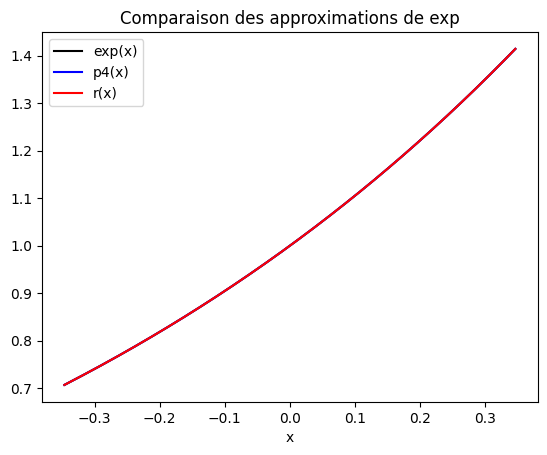

In [56]:
x = np.linspace(-np.log(2)/2,np.log(2)/2, 250)

fig, ax = plt.subplots()

ax.plot(x, np.exp(x), color="black", label="exp(x)")
ax.plot(x, p4(x), color="blue", label="p4(x)")
ax.plot(x, fct_r(x), color="red", label="r(x)")

ax.set_xlabel("x")
ax.set_title("Comparaison des approximations de exp")
ax.legend()

## Question 1b)

Tracer sur un même graphique la fonction, sur l’intervalle $[-\ln(2)/2,\ln(2)/2]$, les fonctions erreurs
\begin{align}
    e_1(x) &= \exp(x)-p_4(x)\\
    e_2(x) &= \exp(x) - r(x)
\end{align}

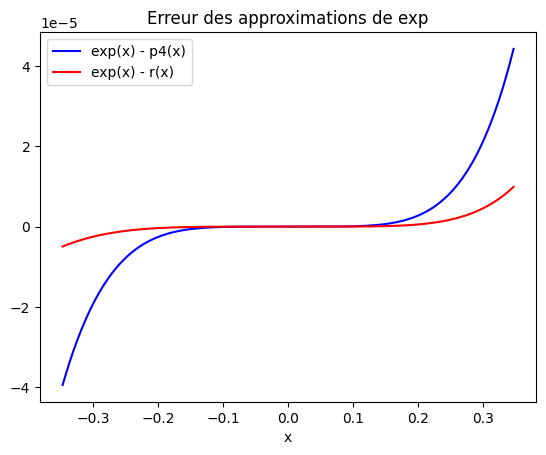

In [57]:
fig, ax = plt.subplots()

ax.plot(x, np.exp(x) - p4(x), color="blue", label="exp(x) - p4(x)")
ax.plot(x, np.exp(x) - fct_r(x), color="red", label="exp(x) - r(x)")

ax.set_xlabel("x")
ax.set_title("Erreur des approximations de exp")
ax.legend()

## Question 1c)

Commentez les résultats obtenus.



# Question 2

Soit l’équation $ax^2+bx+c$ où $a,b$ et $c$ sont des réels et $a \neq 0$. Des racines
réelles n’existent que si le discriminant $\Delta = b^2-4ac$ est positif ou nul. Si $\Delta=0$,
on aura la racine double $-\frac{b}{2a}$

## Question 2a)

Écrire une fonction avec trois arguments en entrée (les coefficients a, b et c) et un argument en sortie, le vecteur R contenant
les deux racines du polynôme. Dans le cas de racines doubles, mettre 2 fois la même valeur dans R. S’il n’y a pas de racines réelles, mettre des NaN dans R.

In [58]:
def racines(a,b,c):

    R = np.zeros(2)
    
    delta = b**2-4*a*c

    if delta < 0:
        R[:] = np.nan
    elif np.isclose(delta, 0):
        R[:] = -b/(2*a)
    else:
        R[0] = (-b + np.sqrt(delta))/(2*a)
        R[1] = (-b - np.sqrt(delta))/(2*a)

    return R

## Question 2b)

Tester votre fonction avec les valeurs suivantes:
\begin{align}
    a &= 1 \qquad &&b = -2 \quad &c = 1\\
    a &= 1 \qquad &&b = -3 \quad &c = 2\\
    a &= 4 \qquad &&b = 0 \quad &c = 1
\end{align}

In [59]:
(a1, b1, c1) = (1, -2, 1)
(a2, b2, c2) = (1, -3, 2)
abc3 = (4, 0, 1)

In [60]:
racines(a1,b1,c1)

array([1., 1.])

In [61]:
racines(a2,b2,c2)

array([2., 1.])

In [62]:
racines(*abc3)

array([nan, nan])

# Question 3

Nous cherchons un algorithme pour estimer la valeur de $\pi$. Une méthode est basée sur le fait que le périmètre d’un cercle de rayon $1/2$ est $\pi$. Pour estimer la valeur de $\pi$, il suffit alors d’estimer le périmètre d’un cercle de rayon $1/2$. L’idée est donc d’inscrire des polygones réguliers dans le cercle et de calculer le périmètre du polygone.

Par exemple, si on inscrit un carré, on vérifie facilement que le périmètre est $2\sqrt{2}$, ce qui est une approximation grossière de $\pi$. En augmentant le nombre de côtés du polygone, on s’approche de plus en plus du périmètre du cercle et donc de $\pi$. Nous noterons pn le périmètre du polygone ayant $2^n$ côtés (par exemple, $p_2=2\sqrt{2}$) et on assumera que la formule de récurrence suivante est vraie pour $n=3,4,\ldots$:
$$
    \begin{cases} r_{n+1} = \frac{r_n}{2 + \sqrt{4 - r_n}} \\
                            p_{n+1} = 2^n\sqrt{r_{n+1}}\end{cases}
$$

où $r_3 = \frac{2}{2+\sqrt{2}}$


## Question 3a)

Écrire un script qui tracera le cercle de rayon $1/2$ ainsi que le polygone inscrit ayant $2^n$ côtés, pour $n=2,3,4$.

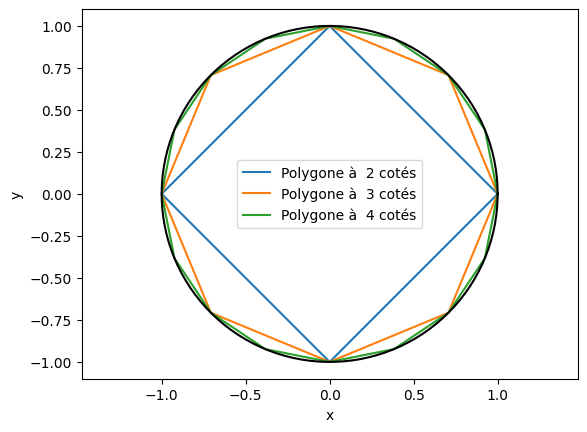

In [63]:
fig, ax = plt.subplots()

theta_fine = np.linspace(0,2*np.pi,250)

for t in range(2,5):
    upper_coordinates = np.array([[np.cos(theta), np.sin(theta)] for theta in np.linspace(0, 2*np.pi, 2**t + 1)]) 
    ax.plot(upper_coordinates[:,0], upper_coordinates[:,1], label=f"Polygone à {t:2d} cotés")

upper_coordinates_circle = np.array([[np.cos(theta), np.sin(theta)] for theta in theta_fine]) 
ax.plot(upper_coordinates_circle[:,0], upper_coordinates_circle[:,1], color="black")

ax.axis("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")

ax.legend()

## Question 3b)

Écrire un script qui calculera $p_n$ pour $n=4,5,\ldots,30$ en utilisant cet algorithme. Afficher, sous forme d’un tableau (utiliser un DataFrame de la librarie Pandas) et avec toute la précision disponible, les valeurs de $n,p_n$ ainsi que l’erreur absolue commise.

In [64]:
rn = np.zeros(31) 
pn = np.zeros(31)

rn[3] = 2/(2+np.sqrt(2))

for t in range(3,30):
    rn[t+1] = rn[t] / (2 + np.sqrt(4-rn[t]))
    pn[t+1] = 2**t * np.sqrt(rn[t+1])

err_abs = np.abs(np.pi - pn)

# Données à affichées dans un dictionnaire
data_q3 = {"n": np.arange(0,31), "pn": pn, "err_abs": err_abs}

# Création d'un objet pandas.DataFrame pour l'affichage en tableau 
data_q3_panda = pd.DataFrame(data_q3)

# Formattage du tableau selon la colonne
format_table = {"n": "{:5d}", "pn": "{:.15f}", "err_abs": "{:.15e}"}

# Affichage de l'objet pandas.DataFrame contenant les informations formattées 
# La méthode hide(axis="index") permet d'ôter la colonne d'index présente par défaut
data_q3_panda.style.format(format_table).hide(axis="index")

n,pn,err_abs
0,0.000000000000000,3.141592653589793e+00
1,0.000000000000000,3.141592653589793e+00
2,0.000000000000000,3.141592653589793e+00
3,0.000000000000000,3.141592653589793e+00
4,3.121445152258052,2.014750133174070e-02
5,3.136548490545939,5.044163043853800e-03
6,3.140331156954753,1.261496635040160e-03
7,3.141277250932773,3.154026570202362e-04
8,3.141513801144301,7.885244549177273e-05
9,3.141572940367091,1.971322270177822e-05


## Question 3c)

Trouver le nombre de chiffres significatifs de $p_{15}$ et de $p_{24}$

In [65]:
def nb_cs(app, err_abs):
    pos_premier = np.floor(np.log10(app))

    pos_dernier_cs = np.ceil(np.log10(2*err_abs))

    nb_cs = pos_premier - pos_dernier_cs + 1

    return int(nb_cs)

In [66]:
n = 15
print(f"Nb c.s. pour p_{n} = {nb_cs(pn[n], err_abs[n]):2d}")
n = 24
print(f"Nb c.s. pour p_{n} = {nb_cs(pn[n], err_abs[n]):2d}")

Nb c.s. pour p_15 =  9
Nb c.s. pour p_24 = 14
